# MINTverse in one district

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CosmoNaught/MINTverse/blob/main/MINTverse-tutorial.ipynb)

`estimint` turns a measured prevalence into a transmission intensity, and `stateMINT` predicts how
prevalence and clinical cases respond to a net campaign. `run_scenarios` runs both. We build a few
campaigns, plot them, add up the cases, and save the result to CSV.

## Setup

Install both packages. You install `mintstate` but import `stateMINT`. On Colab, accept the restart
prompt if one appears, then run the rest.

In [ ]:
%pip install -q mintstate estimint matplotlib

In [2]:
import os, warnings, logging

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from estimint import Scenario, EirTarget, run_scenarios

plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=["#3987e5", "#199e70", "#c98500", "#9085e9", "#e66767"])

## Scenarios

A `Scenario` is one setting and one campaign. The shared setting goes in a dictionary, and each
campaign sets only its `_future` fields. Leave those out and the nets are withdrawn at the campaign,
which is the first scenario below.

In [3]:
district = dict(
    res_use=0.30,    # pyrethroid resistance
    Q0=0.85,         # share of bites taken on humans
    phi=0.80,        # share of bites taken in bed
    seasonal=0.0,    # 0 perennial, 1 strongly seasonal
    irs=0.0,         # current spraying
    py_only=0.70,    # nets in place today
    eir_target=EirTarget(0.45, "prevalence"),   # measured under-5 prevalence
)

scenarios = [
    Scenario(name="Withdraw", **district),
    Scenario(name="Pyrethroid-only", **district, net_type_future="pyrethroid_only", itn_future=0.70),
    Scenario(name="PBO", **district, net_type_future="pyrethroid_pbo", itn_future=0.70),
    Scenario(name="Pyrrole", **district, net_type_future="pyrethroid_pyrrole", itn_future=0.70),
    Scenario(name="PBO + IRS + LSM", **district, net_type_future="pyrethroid_pbo", itn_future=0.70,
             irs_future=0.60, lsm=0.30),
]

## Run

`run_scenarios` converts the nets to a killing effect, inverts the prevalence to a baseline EIR, and
calls the emulator once for all five. Only the campaign differs, so the baseline EIR is shared.

In [4]:
results = run_scenarios(scenarios)

results[["name", "net_future", "dn0_future", "eir_baseline",
         "prev_y9", "prev_endline", "cases_endline"]].round(3)

,name,net_future,dn0_future,eir_baseline,prev_y9,prev_endline,cases_endline
0,Withdraw,none,0.000,31.96,0.456,0.498,2.127
1,Pyrethroid-only,pyrethroid_only,0.311,31.96,0.456,0.484,2.433
2,PBO,pyrethroid_pbo,0.485,31.96,0.456,0.470,2.412
3,Pyrrole,pyrethroid_pyrrole,0.550,31.96,0.456,0.464,2.390
4,PBO + IRS + LSM,pyrethroid_pbo,0.485,31.96,0.456,0.038,0.165


The two trajectory columns, `prevalence` and `cases`, hold 157 fortnightly steps each. Build the time
axis once, in years from the campaign.

In [5]:
step_days = 14
day = 2190 + step_days * np.arange(157)   # stateMINT's day grid
years = (day - 3285) / 365                # years from the campaign
campaign = int(np.argmin(np.abs(years)))  # the step the campaign lands on

## Prevalence

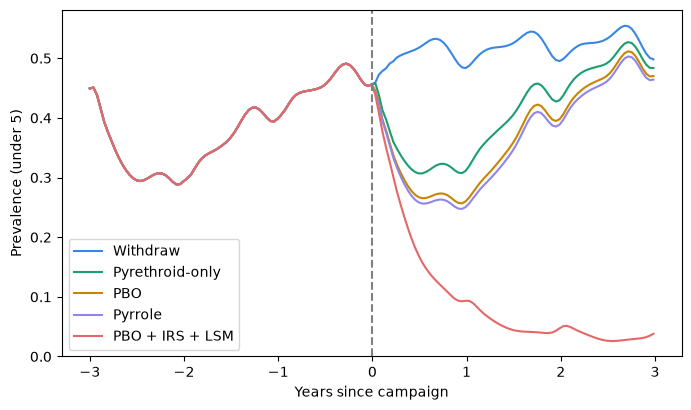

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for _, row in results.iterrows():
    ax.plot(years, row["prevalence"], label=row["name"])

ax.axvline(0, color="grey", ls="--")
ax.set_xlabel("Years since campaign")
ax.set_ylabel("Prevalence (under 5)")
ax.set_ylim(0, None)
ax.legend()

plt.show()

The five lines share the run-up on the left, then separate at the campaign. The red combination
scenario drops far below the rest, because spraying and larviciding do not decay on a net's clock.

## Clinical cases

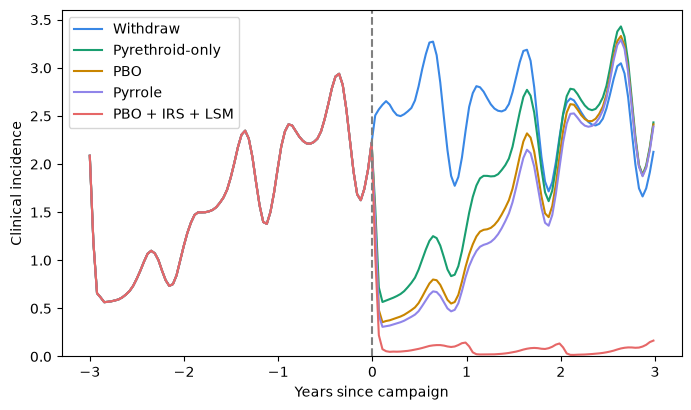

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for _, row in results.iterrows():
    ax.plot(years, row["cases"], label=row["name"])

ax.axvline(0, color="grey", ls="--")
ax.set_xlabel("Years since campaign")
ax.set_ylabel("Clinical incidence")
ax.set_ylim(0, None)
ax.legend()

plt.show()

Incidence swings from step to step, and the net scenarios drift back towards withdrawal by the third
year as their insecticide fades.

## Cases averted

The last step on its own is noisy and misleading, so add up the cases from the campaign onwards and
compare each campaign with withdrawal.

In [8]:
rows = []
for _, row in results.iterrows():
    total = float(row["cases"][campaign:].sum()) * step_days
    rows.append({"name": row["name"], "total_cases": total})

table = pd.DataFrame(rows).set_index("name")

withdraw = table.loc["Withdraw", "total_cases"]
table["averted"] = withdraw - table["total_cases"]
table["averted_pct"] = 100 * table["averted"] / withdraw

table.sort_values("averted", ascending=False).round(1)

,total_cases,averted,averted_pct
name,,,
PBO + IRS + LSM,124.4,2671.7,95.6
Pyrrole,1692.3,1103.8,39.5
PBO,1789.8,1006.3,36.0
Pyrethroid-only,2083.4,712.7,25.5
Withdraw,2796.1,0.0,0.0


Every campaign averts cases against withdrawal, and the combination scenario averts almost all of
them. The ranking follows `dn0_future`, so it is only as good as the resistance estimate behind it.

## Export

Two columns hold arrays and will not fit a CSV cell, so save the scalars and the trajectories in
separate files. The long trajectory file is the shape `ggplot2` and `dplyr` expect.

In [9]:
os.makedirs("outputs", exist_ok=True)

results.drop(columns=["prevalence", "cases"]).to_csv("outputs/summary.csv", index=False)

frames = []
for _, row in results.iterrows():
    frames.append(pd.DataFrame({
        "name": row["name"], "day": day, "years": years,
        "prevalence": row["prevalence"], "cases": row["cases"],
    }))

pd.concat(frames, ignore_index=True).to_csv("outputs/trajectories.csv", index=False)

print("wrote outputs/summary.csv and outputs/trajectories.csv")

wrote outputs/summary.csv and outputs/trajectories.csv


Read the trajectories straight into R.

```r
library(readr)
library(ggplot2)

traj <- read_csv("outputs/trajectories.csv")

ggplot(traj, aes(years, prevalence, colour = name)) +
  geom_line() +
  geom_vline(xintercept = 0, linetype = "dashed") +
  theme_minimal()
```

Please see [Running scenarios](https://cosmonaught.github.io/MINTverse/chapters/06-scenarios/run-scenarios.html)
for every `Scenario` field, and [Trajectories and
cases](https://cosmonaught.github.io/MINTverse/chapters/06-scenarios/comparing.html) for the plots
and the burden in more depth.